GPUs detectadas: 0
Rodando em CPU — paralelismo configurado para 2 threads.
Using dataset root: 101_ObjectCategories (97 categorias)
finished indexing 6209 images from 97 categories
train / validation / test split: 4346, 931, 932


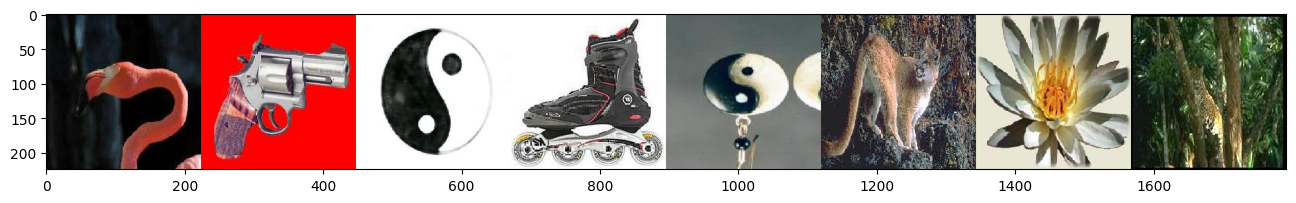

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 97)             │        24,929 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 97)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233,473 (4.71 MB)

 Trainable params: 1,233,473 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

136/136 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.0543 - loss: 4.4695 - val_accuracy: 0.0666 - val_loss: 4.3161


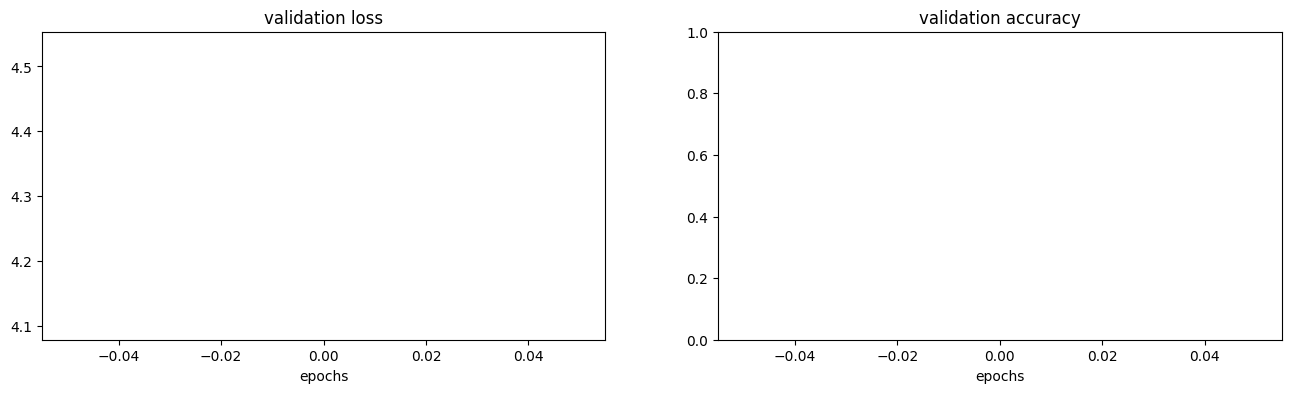

Test loss (baseline do zero): 4.323352336883545
Test accuracy (baseline do zero): 0.06330472230911255
Tempo total (baseline do zero): 363.1s
VGG16 (sem o topo) carregada — dimensao das features: 512


In [ ]:
# Importacoes
import os
import random
import shutil
import tarfile
import time
import urllib.request
import zipfile

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping

# Configuracoes gerais
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
FEATURE_BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42
TRAIN_BASELINE_FROM_SCRATCH = True

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Detecta GPU ou configura threads de CPU
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detectadas: {len(gpus)}")
if not gpus:
    n_cpus = os.cpu_count() or 4
    try:
        tf.config.threading.set_intra_op_parallelism_threads(n_cpus)
        tf.config.threading.set_inter_op_parallelism_threads(n_cpus)
        print(f"Rodando em CPU — paralelismo configurado para {n_cpus} threads.")
    except RuntimeError:
        print("Nao foi possivel configurar threads de CPU manualmente.")
else:
    print("GPU disponivel — sera usada automaticamente para acelerar o treino.")

# Baixa e extrai o dataset Caltech-101, se necessario
CALTECH101_URL = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1"
DOWNLOAD_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept": "*/*",
}


def _download(url, dest):
    request = urllib.request.Request(url, headers=DOWNLOAD_HEADERS)
    with urllib.request.urlopen(request) as response:
        total = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        with open(dest, "wb") as out_file:
            while True:
                chunk = response.read(1024 * 256)
                if not chunk:
                    break
                out_file.write(chunk)
                downloaded += len(chunk)
                if total:
                    pct = downloaded * 100 // total
                    print(f"\rBaixando Caltech-101... {pct}%", end="", flush=True)
    print()


def ensure_dataset():
    if os.path.isdir('101_ObjectCategories'):
        return '101_ObjectCategories'
    if os.path.isdir('Data_set'):
        return 'Data_set'

    print("Nenhum dataset encontrado localmente — baixando o Caltech-101 (~137 MB)...")
    zip_path = 'caltech-101.zip'
    _download(CALTECH101_URL, zip_path)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall('.')

    inner_tar = os.path.join('caltech-101', '101_ObjectCategories.tar.gz')
    with tarfile.open(inner_tar) as tar:
        tar.extractall('.')

    for leftover in (zip_path, 'caltech-101', '__MACOSX'):
        if os.path.isdir(leftover):
            shutil.rmtree(leftover, ignore_errors=True)
        elif os.path.isfile(leftover):
            os.remove(leftover)

    if not os.path.isdir('101_ObjectCategories'):
        raise FileNotFoundError('Falha ao preparar o dataset 101_ObjectCategories apos o download.')

    print("Dataset pronto.")
    return '101_ObjectCategories'


root = ensure_dataset()

# Lista as categorias do dataset
exclude = ['BACKGROUND_Google', 'Motorbikes', 'airplanes', 'Faces_easy', 'Faces'] if root == '101_ObjectCategories' else []

categories = sorted(
    entry for entry in os.listdir(root)
    if os.path.isdir(os.path.join(root, entry)) and not entry.startswith('.') and entry not in exclude
)
if not categories:
    raise ValueError(f'No category subfolders found in dataset root: {root}')

num_classes = len(categories)
print(f"Using dataset root: {root} ({num_classes} categorias)")

# Indexa as imagens e separa treino, validacao e teste
file_paths, file_labels = [], []
for class_idx, category in enumerate(categories):
    category_dir = os.path.join(root, category)
    for dp, _dn, filenames in os.walk(category_dir):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in ('.jpg', '.png', '.jpeg'):
                file_paths.append(os.path.join(dp, f))
                file_labels.append(class_idx)

if not file_paths:
    raise ValueError(f"Nenhuma imagem encontrada no diretorio '{root}'.")

combined = list(zip(file_paths, file_labels))
random.shuffle(combined)
file_paths, file_labels = map(list, zip(*combined))

n_total = len(file_paths)
train_split, val_split = 0.7, 0.15
idx_val = int(train_split * n_total)
idx_test = int((train_split + val_split) * n_total)

splits = {
    'train': (file_paths[:idx_val], file_labels[:idx_val]),
    'val':   (file_paths[idx_val:idx_test], file_labels[idx_val:idx_test]),
    'test':  (file_paths[idx_test:], file_labels[idx_test:]),
}

if any(len(paths) == 0 for paths, _ in splits.values()):
    raise ValueError('Dataset pequeno demais para o split 70/15/15. Adicione mais imagens.')

print("finished indexing %d images from %d categories" % (n_total, num_classes))
print("train / validation / test split: %d, %d, %d" % (
    len(splits['train'][0]), len(splits['val'][0]), len(splits['test'][0])
))

# Monta o pipeline de carregamento das imagens
def _decode_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    label = tf.one_hot(label, num_classes)
    return img, label


CACHE_DIR = '.tf_cache'
shutil.rmtree(CACHE_DIR, ignore_errors=True)
os.makedirs(CACHE_DIR, exist_ok=True)


def build_raw_dataset(paths, labels, cache_name):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(os.path.join(CACHE_DIR, cache_name))
    return ds


def finalize_dataset(raw_ds, preprocess_fn, training, batch_size=BATCH_SIZE):
    ds = raw_ds
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


raw_datasets = {name: build_raw_dataset(*paths_labels, cache_name=name) for name, paths_labels in splits.items()}

# Mostra algumas imagens de exemplo
if file_paths:
    sample_idx = random.sample(range(len(file_paths)), k=min(8, len(file_paths)))
    sample_imgs = [load_img(file_paths[i], target_size=IMG_SIZE) for i in sample_idx]
    concat_image = np.concatenate([np.asarray(img) for img in sample_imgs], axis=1)
    plt.figure(figsize=(16, 4))
    plt.imshow(concat_image)
    plt.show()

# Treina uma CNN do zero (baseline)
history = None
model = None

if TRAIN_BASELINE_FROM_SCRATCH:
    t0 = time.perf_counter()

    scratch_train_ds = finalize_dataset(raw_datasets['train'], lambda x: x / 255.0, training=True)
    scratch_val_ds = finalize_dataset(raw_datasets['val'], lambda x: x / 255.0, training=False)
    scratch_test_ds = finalize_dataset(raw_datasets['test'], lambda x: x / 255.0, training=False)

    model = Sequential()
    model.add(Input(shape=(*IMG_SIZE, 3)))
    model.add(Conv2D(32, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(32, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Dropout(0.25))

    model.add(Conv2D(32, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(32, (3, 3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(256))
    model.add(Activation('relu'))

    model.add(Dropout(0.5))

    model.add(Dense(num_classes))
    model.add(Activation('softmax'))

    model.summary()

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    early_stop_scratch = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        scratch_train_ds,
        epochs=15,
        validation_data=scratch_val_ds,
        callbacks=[early_stop_scratch],
        shuffle=False,
    )

    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_subplot(121)
    ax.plot(history.history["val_loss"])
    ax.set_title("validation loss")
    ax.set_xlabel("epochs")
    ax2 = fig.add_subplot(122)
    ax2.plot(history.history.get("val_accuracy", history.history.get("val_acc")))
    ax2.set_title("validation accuracy")
    ax2.set_xlabel("epochs")
    ax2.set_ylim(0, 1)
    plt.show()

    loss, accuracy = model.evaluate(scratch_test_ds, verbose=0)
    print('Test loss (baseline do zero):', loss)
    print('Test accuracy (baseline do zero):', accuracy)
    print(f"Tempo total (baseline do zero): {time.perf_counter() - t0:.1f}s")
else:
    print("TRAIN_BASELINE_FROM_SCRATCH=False — pulando o treino do modelo do zero.")

# Extrai as features das imagens com a VGG16
t0 = time.perf_counter()

vgg_base = keras.applications.VGG16(
    weights='imagenet', include_top=False, pooling='avg', input_shape=(*IMG_SIZE, 3)
)
vgg_base.trainable = False
feature_dim = vgg_base.output_shape[-1]
print(f"VGG16 (sem o topo) carregada — dimensao das features: {feature_dim}")

vgg_train_ds = finalize_dataset(raw_datasets['train'], preprocess_input, training=False, batch_size=FEATURE_BATCH_SIZE)
vgg_val_ds = finalize_dataset(raw_datasets['val'], preprocess_input, training=False, batch_size=FEATURE_BATCH_SIZE)
vgg_test_ds = finalize_dataset(raw_datasets['test'], preprocess_input, training=False, batch_size=FEATURE_BATCH_SIZE)


def extract_features(ds):
    feats, labs = [], []
    for batch_x, batch_y in ds:
        feats.append(vgg_base(batch_x, training=False).numpy())
        labs.append(batch_y.numpy())
    return np.concatenate(feats), np.concatenate(labs)


train_feats, y_train = extract_features(vgg_train_ds)
val_feats, y_val = extract_features(vgg_val_ds)
test_feats, y_test = extract_features(vgg_test_ds)
print(f"Extracao de features concluida em {time.perf_counter() - t0:.1f}s "
      f"(shapes: {train_feats.shape}, {val_feats.shape}, {test_feats.shape})")

# Treina o classificador sobre as features
t0 = time.perf_counter()

classifier = Sequential(name='classifier_head')
classifier.add(Input(shape=(feature_dim,)))
classifier.add(Dense(256, activation='relu'))
classifier.add(Dropout(0.5))
classifier.add(Dense(num_classes, activation='softmax'))
classifier.summary()

classifier.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop_transfer = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history2 = classifier.fit(
    train_feats, y_train,
    batch_size=BATCH_SIZE,
    epochs=30,
    validation_data=(val_feats, y_val),
    callbacks=[early_stop_transfer],
)

loss, accuracy = classifier.evaluate(test_feats, y_test, verbose=0)
print('Test loss (transfer learning):', loss)
print('Test accuracy (transfer learning):', accuracy)
print(f"Tempo total (transfer learning, so o classificador): {time.perf_counter() - t0:.1f}s")

model_new = Model(inputs=vgg_base.input, outputs=classifier(vgg_base.output))

# Compara os dois modelos
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(121)
if history is not None:
    ax.plot(history.history["val_loss"], label="do zero")
ax.plot(history2.history["val_loss"], label="transfer learning")
ax.set_title("validation loss")
ax.set_xlabel("epochs")
ax.legend()

ax2 = fig.add_subplot(122)
if history is not None:
    ax2.plot(history.history.get("val_accuracy", history.history.get("val_acc")), label="do zero")
ax2.plot(history2.history.get("val_accuracy", history2.history.get("val_acc")), label="transfer learning")
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)
ax2.legend()
plt.show()

# Faz a predicao de uma imagem nova, mostrando a imagem e o ROI (Grad-CAM)
def get_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x


LAST_CONV_LAYER = 'block5_conv3'


def make_gradcam_heatmap(img_array, pred_index=None):
    grad_model = Model(
        inputs=vgg_base.input,
        outputs=[vgg_base.get_layer(LAST_CONV_LAYER).output, classifier(vgg_base.output)]
    )
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        tape.watch(conv_output)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index, preds.numpy()[0]


def show_prediction_with_roi(img_path, box_threshold=0.6):
    img, x = get_image(img_path)
    heatmap, pred_index, probabilities = make_gradcam_heatmap(x)
    predicted_class = os.path.basename(categories[pred_index])
    confidence = probabilities[pred_index] * 100

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    heatmap_resized = np.clip(heatmap_resized, 0, 1)

    mask = heatmap_resized >= (heatmap_resized.max() * box_threshold)
    ys, xs = np.where(mask)
    if len(xs) > 0:
        x0, y0, x1, y1 = xs.min(), ys.min(), xs.max(), ys.max()
    else:
        x0, y0, x1, y1 = 0, 0, IMG_SIZE[0] - 1, IMG_SIZE[1] - 1

    original = np.array(img).astype('uint8')

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(original)
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=3, edgecolor='lime', facecolor='none'))
    ax.text(x0, max(y0 - 6, 0), f"{predicted_class} {confidence:.1f}%", color='black', fontsize=12,
             weight='bold', bbox=dict(facecolor='lime', edgecolor='none', pad=3))
    ax.axis('off')
    plt.show()

    print(f"Predicao concluida para: {img_path}")
    print(f"Classe prevista: {predicted_class} (confianca: {confidence:.1f}%)")


try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

path_custom = 'Data_set/elemento_A/07-03-44-588_96x96.jpg'
path_local = None
for dp, dn, filenames in os.walk(root):
    for f in filenames:
        if os.path.splitext(f)[1].lower() in ('.jpg', '.png', '.jpeg'):
            path_local = os.path.join(dp, f)
            break
    if path_local:
        break

img_path = path_custom if os.path.exists(path_custom) else path_local

if img_path and os.path.exists(img_path):
    show_prediction_with_roi(img_path)
else:
    print("Erro: Nenhuma imagem encontrada para predicao. Verifique os caminhos.")